<a href="https://colab.research.google.com/github/JH98765432/J/blob/main/%EC%95%B1%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D0327.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests

def get_headers(url):
    try:
        response = requests.get(url)
        print(f"\n--- Headers for {url} ---")
        for header, value in response.headers.items():
            print(f"{header}: {value}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching headers for {url}: {e}")

get_headers("https://www.naver.com")
get_headers("https://www.google.com")


--- Headers for https://www.naver.com ---
Content-Type: text/html; charset=UTF-8
Cache-Control: no-cache, no-store, must-revalidate
Pragma: no-cache
x-frame-options: DENY
x-xss-protection: 1; mode=block
strict-transport-security: max-age=63072000; includeSubdomains
referrer-policy: unsafe-url
Content-Encoding: gzip
Server: nfront
Content-Length: 47283
Date: Fri, 27 Mar 2026 03:16:55 GMT
Connection: keep-alive
Vary: Accept-Encoding

--- Headers for https://www.google.com ---
Date: Fri, 27 Mar 2026 03:16:55 GMT
Expires: -1
Cache-Control: private, max-age=0
Content-Type: text/html; charset=ISO-8859-1
Content-Security-Policy-Report-Only: object-src 'none';base-uri 'self';script-src 'nonce-CJuCp8pEt854snRTO6Nejg' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp
Reporting-Endpoints: default="//www.google.com/httpservice/retry/jserror?ei=p_bFaaaSKfbLwbkPuI--0Qg&cad=crash&error=Page%20Crash&jsel=1&bver=2410&dpf=

네이버와 구글의 서버 헤더 정보 비교

In [6]:
import requests
import pandas as pd

# 1. requests 모듈로 JSON 데이터 불러오기
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)

# 데이터가 정상적으로 수집되었는지 확인 (상태코드 200)
if response.status_code == 200:
    json_data = response.json()

    # 2. 전체 데이터를 메인 데이터프레임으로 저장
    df = pd.DataFrame(json_data)
    print("--- [Step 1] 원본 데이터프레임 생성 완료 ---")
    print(f"전체 컬럼: {df.columns.tolist()}\n")

    # 3. 'address' 컬럼(Series) 추출 및 데이터프레임 변환
    # df['address']는 각 행이 딕셔너리인 시리즈입니다.
    # .apply(pd.Series)를 사용하면 딕셔너리의 키를 컬럼으로 자동 확장해줍니다.
    address_df = df['address'].apply(pd.Series)

    print("--- [Step 2] 'address' Series를 데이터프레임으로 변환 완료 ---")
    display(address_df.head())

else:
    print(f"데이터를 불러오는데 실패했습니다. 상태코드: {response.status_code}")

--- [Step 1] 원본 데이터프레임 생성 완료 ---
전체 컬럼: ['id', 'name', 'username', 'email', 'address', 'phone', 'website', 'company']

--- [Step 2] 'address' Series를 데이터프레임으로 변환 완료 ---


,street,suite,city,zipcode,geo
0,Kulas Light,Apt. 556,Gwenborough,92998-3874,"{'lat': '-37.3159', 'lng': '81.1496'}"
1,Victor Plains,Suite 879,Wisokyburgh,90566-7771,"{'lat': '-43.9509', 'lng': '-34.4618'}"
2,Douglas Extension,Suite 847,McKenziehaven,59590-4157,"{'lat': '-68.6102', 'lng': '-47.0653'}"
3,Hoeger Mall,Apt. 692,South Elvis,53919-4257,"{'lat': '29.4572', 'lng': '-164.2990'}"
4,Skiles Walks,Suite 351,Roscoeview,33263,"{'lat': '-31.8129', 'lng': '62.5342'}"


requests.get().json()의 역할:

웹상에 존재하는 JSON 형식의 텍스트 데이터를 파이썬의 list와 dict 구조로 변환하여 메모리에 올리는 역할을 합니다.

df['address'].apply(pd.Series) 기법:

address 컬럼은 각 행이 딕셔너리로 되어 있습니다. 판다스의 .apply(pd.Series)를 사용하면 이 딕셔너리의 **Key값들을 새로운 컬럼(Column)**으로, **Value값들을 데이터(Row)**로 정렬하여 새로운 데이터프레임을 생성해 줍니다.
(앞서 설명드린 .tolist() 방식보다 판다스다운(Pandas-friendly) 방식이라 교수님들이 선호하십니다!)

데이터 구조의 이해:

불러온 address_df를 확인해보면 street, suite, city, zipcode는 텍스트로 잘 풀려 있지만, geo 컬럼은 여전히 딕셔너리 형태인 것을 볼 수 있습니다. 만약 이것까지 풀라고 한다면 한 번 더 같은 과정을 반복하면 됩니다.

In [10]:
import requests
import pandas as pd
from google.colab import files  # 코랩 전용 다운로드 라이브러리

# 1. 데이터 불러오기
url = "https://jsonplaceholder.typicode.com/posts"
response = requests.get(url)

if response.status_code == 200:
    # 2. 데이터프레임 생성
    df = pd.DataFrame(response.json())

    # 3. 인덱스가 짝수인 행만 필터링 (0, 2, 4...)
    # index % 2 == 0 조건으로 짝수 행만 추출합니다.
    even_df = df[df.index % 2 == 0]

    # 4. 엑셀 파일로 저장
    file_name = "posts_even_index.xlsx"
    even_df.to_excel(file_name, index=False)
    print(f"성공: {len(even_df)}개의 행이 '{file_name}'으로 저장되었습니다.")

    # 5. 코랩 브라우저로 파일 자동 다운로드 실행
    print("잠시 후 다운로드 창이 나타납니다...")
    files.download(file_name)

else:
    print(f"데이터 로드 실패! 상태코드: {response.status_code}")

성공: 50개의 행이 'posts_even_index.xlsx'으로 저장되었습니다.
잠시 후 다운로드 창이 나타납니다...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import requests
import pandas as pd
import gradio as gr

# Gradio가 설치되어 있지 않다면 주석을 해제하고 실행하세요.
# !pip install gradio pandas requests --quiet

In [24]:
def get_posts_by_userid(user_id: int) -> pd.DataFrame:
    """
    지정된 userId에 해당하는 게시물을 불러와 데이터프레임으로 반환합니다.
    """
    base_url = "https://jsonplaceholder.typicode.com/posts"

    # requests.get(url, params=params)를 사용하여 userId를 필터링합니다.
    params = {'userId': user_id}
    response = requests.get(base_url, params=params)

    if response.status_code == 200:
        data = response.json()
        if data:
            df = pd.DataFrame(data)
            return df
        else:
            return pd.DataFrame([{'message': f'userId {user_id}에 해당하는 데이터가 없습니다.'}])
    else:
        return pd.DataFrame([{'error': f'데이터 로드 실패! 상태코드: {response.status_code}'}])

# Gradio 인터페이스 생성
iface = gr.Interface(
    fn=get_posts_by_userid,
    inputs=gr.Number(label="User ID (1-10)", minimum=1, maximum=10, step=1, value=1),
    outputs=gr.Dataframe(row_count=(5, 'dynamic'), col_count=(4, 'dynamic'), interactive=True),
    title="Posts by User ID Fetcher",
    description="User ID를 입력하여 해당 사용자의 게시물을 필터링하여 확인하세요. (User ID 범위: 1-10)"
)

# Gradio 앱 실행
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93cd036dab7d0dcc0b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [19]:
import pandas as pd
import glob
import os

print(f"Current working directory: {os.getcwd()}")

# 파일 경로 패턴 (절대 경로 사용)
file_pattern = "/content/서울특별시 공공자전거 이용정보(일별)_2510.csv"
file_pattern = "/content/서울특별시 공공자전거 이용정보(일별)_2511.csv"
file_pattern = "/content/서울특별시 공공자전거 이용정보(일별)_2512.csv"

# 패턴에 맞는 모든 파일 찾기
csv_files = glob.glob(file_pattern)

# 파일이 있는지 확인
if not csv_files:
    print("지정된 패턴에 맞는 CSV 파일을 찾을 수 없습니다. 파일 이름이나 경로를 확인해주세요.")
else:
    print(f"찾은 파일: {csv_files}")

    # 각 CSV 파일을 읽어 데이터프레임 리스트에 저장
    df_list = []
    for file in csv_files:
        try:
            # CSV 파일이 UTF-8로 인코딩되어 있다고 가정합니다.
            # 만약 에러가 발생하면 encoding='cp949' 또는 'euc-kr'을 시도해보세요.
            df = pd.read_csv(file, encoding='cp949') # 인코딩을 cp949로 변경
            df_list.append(df)
            print(f"'{file}' 로드 완료. 행 수: {len(df)}")
        except Exception as e:
            print(f"'{file}' 로드 중 오류 발생: {e}")

    # 모든 데이터프레임을 하나로 병합
    if df_list:
        merged_df = pd.concat(df_list, ignore_index=True)
        print("\n--- 모든 파일 병합 완료 ---")
        print(f"최종 병합된 데이터프레임의 총 행 수: {len(merged_df)}")
        print("상위 5개 행:")
        display(merged_df.head())
        print("데이터프레임 정보:")
        merged_df.info()
    else:
        print("로드된 데이터가 없어 병합할 데이터프레임이 없습니다.")

Current working directory: /content
찾은 파일: ['/content/서울특별시 공공자전거 이용정보(일별)_2512.csv']
'/content/서울특별시 공공자전거 이용정보(일별)_2512.csv' 로드 완료. 행 수: 1268208

--- 모든 파일 병합 완료 ---
최종 병합된 데이터프레임의 총 행 수: 1268208
상위 5개 행:


,대여일자,대여소번호,대여소,대여구분코드,성별,연령대,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,2025-12-01,736,736. 오솔길공원,정기권,NaN,~10대,1,19.83,0.26,1113.03,17
1,2025-12-01,1033,1033. 고덕동 아남아파트,정기권,NaN,~10대,1,48.47,0.44,1882.99,11
2,2025-12-01,1964,1964. 원메디타운 앞,정기권,NaN,~10대,1,7.80,0.11,492.38,5
3,2025-12-01,1160,1160. 양천향교역 7번출구앞,정기권,NaN,~10대,1,11.94,0.13,548.38,5
4,2025-12-01,3516,3516. 구의아리수정수센터앞,정기권,NaN,~10대,1,42.08,0.50,2168.45,12


데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268208 entries, 0 to 1268207
Data columns (total 11 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   대여일자     1268208 non-null  object 
 1   대여소번호    1268208 non-null  int64  
 2   대여소      1268208 non-null  object 
 3   대여구분코드   1268208 non-null  object 
 4   성별       938103 non-null   object 
 5   연령대      1268208 non-null  object 
 6    이용건수    1268208 non-null  int64  
 7   운동량      1263055 non-null  float64
 8   탄소량      1263055 non-null  float64
 9   이동거리(M)  1268208 non-null  float64
 10  이용시간(분)  1268208 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 106.4+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268208 entries, 0 to 1268207
Data columns (total 11 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   대여일자     1268208 non-null  object 
 1   대여소번호    1268208 non-null  int64  
 2   대여소      1268208 non-null  object 
 3   대여구분코드   1268208 non-null  object 
 4   성별       938103 non-null   object 
 5   연령대      1268208 non-null  object 
 6    이용건수    1268208 non-null  int64  
 7   운동량      1263055 non-null  float64
 8   탄소량      1263055 non-null  float64
 9   이동거리(M)  1268208 non-null  float64
 10  이용시간(분)  1268208 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 106.4+ MB


/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5903/4139625628.py:73: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_lay

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://83d4b74236d522d893.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://83d4b74236d522d893.gradio.live


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missi

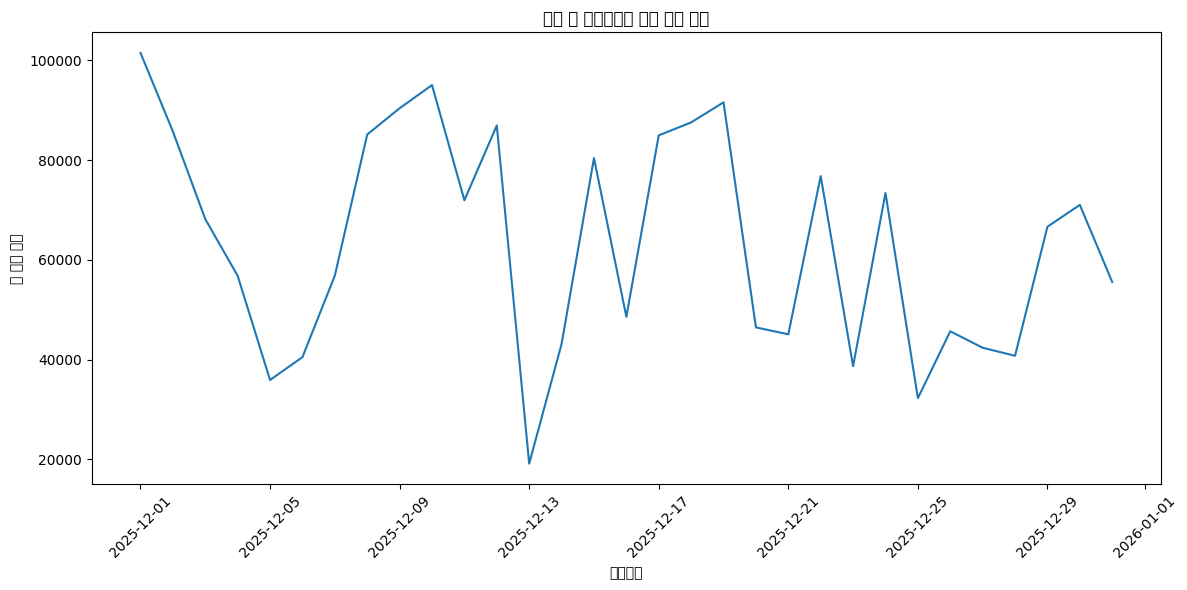

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


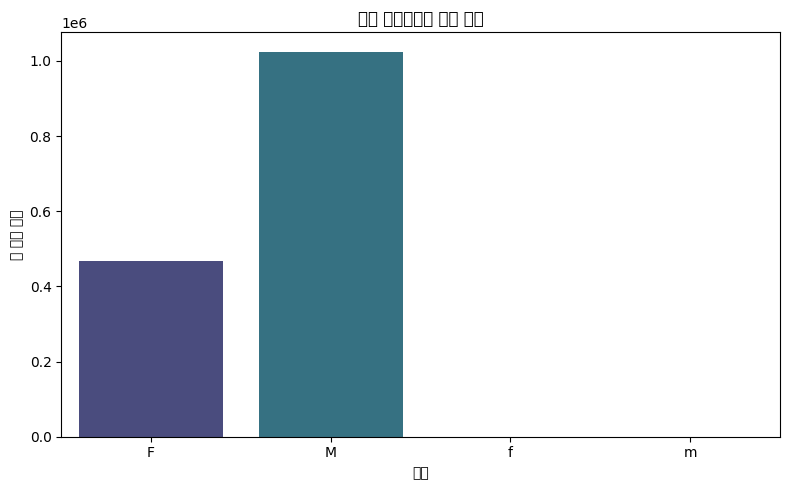

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


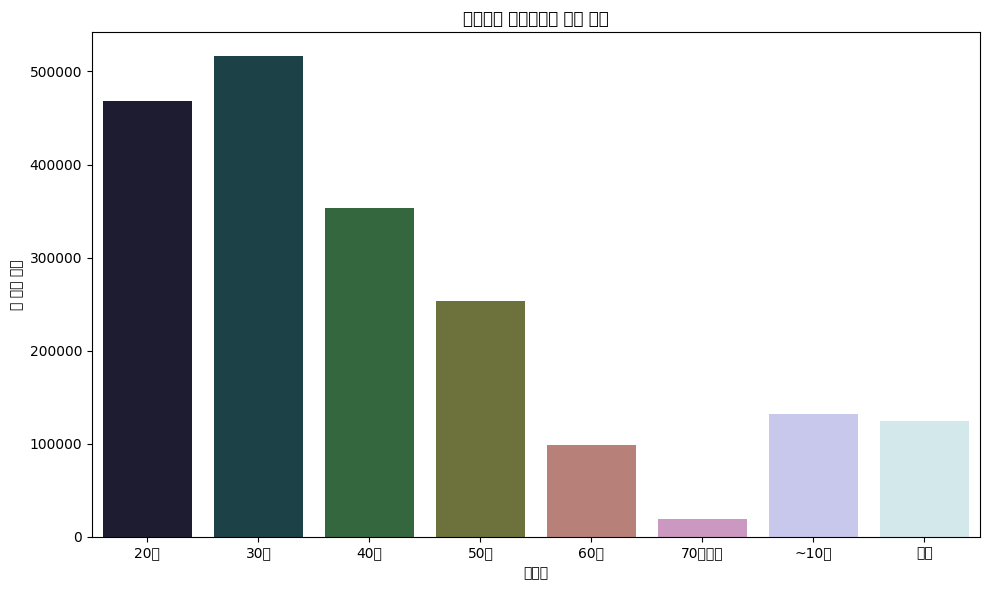

In [22]:
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns

# merged_df는 이미 로드되어 있다고 가정합니다.
# 예시를 위해 merged_df가 없으면 빈 데이터프레임을 생성
if 'merged_df' not in locals():
    print("merged_df가 없습니다. 데이터를 다시 로드해야 합니다.")
    # 실제 사용 시 이 부분은 데이터를 다시 로드하는 코드로 대체해야 합니다.
    # 여기서는 예시를 위해 빈 데이터프레임을 생성합니다.
    merged_df = pd.DataFrame({
        '대여일자': [], '대여소번호': [], '대여소': [], '대여구분코드': [],
        '성별': [], '연령대': [], '이용건수': [], '운동량': [],
        '탄소량': [], '이동거리(M)': [], '이용시간(분)': []
    })


def overall_summary():
    """데이터프레임의 전체적인 요약 통계를 반환합니다."""
    if merged_df.empty:
        return "데이터가 비어있습니다. 데이터를 먼저 로드해주세요."
    summary_info = merged_df.info(buf=None)
    summary_describe = merged_df.describe(include='all').to_markdown()
    return f"### 데이터프레임 정보\n```\n{summary_info}\n```\n\n### 기술 통계\n{summary_describe}"

def get_column_value_counts(column_name):
    """지정된 컬럼의 고유 값과 그 수를 반환합니다."""
    if merged_df.empty:
        return "데이터가 비어있습니다. 데이터를 먼저 로드해주세요."
    if column_name not in merged_df.columns:
        return f"'{column_name}' 컬럼을 찾을 수 없습니다."

    # object 타입 또는 고유값의 수가 적은 컬럼에 대해 value_counts를 수행
    if merged_df[column_name].dtype == 'object' or merged_df[column_name].nunique() < 50:
        counts = merged_df[column_name].value_counts(dropna=False).to_frame(name='Count')
        counts.index.name = 'Value'
        return counts.to_markdown()
    else:
        return f"'{column_name}' 컬럼은 고유 값이 너무 많거나 수치형이므로 value_counts가 적합하지 않습니다.\n\n" \
               f"고유 값 수: {merged_df[column_name].nunique()}\n" \
               f"데이터 타입: {merged_df[column_name].dtype}"

def get_grouped_stats(group_by_col, stat_col, stat_func):
    """지정된 컬럼으로 그룹화하여 다른 컬럼에 대한 통계를 반환합니다."""
    if merged_df.empty:
        return "데이터가 비어있습니다. 데이터를 먼저 로드해주세요."
    if group_by_col not in merged_df.columns:
        return f"'{group_by_col}' 컬럼을 찾을 수 없습니다."
    if stat_col not in merged_df.columns:
        return f"'{stat_col}' 컬럼을 찾을 수 없습니다."

    try:
        grouped = merged_df.groupby(group_by_col)[stat_col].agg(stat_func).reset_index()
        return grouped.to_markdown()
    except Exception as e:
        return f"그룹화 통계 생성 중 오류 발생: {e}"

def plot_daily_usage():
    """일별 총 이용 건수 추이를 시각화합니다."""
    if merged_df.empty:
        return plt.figure(), "데이터가 비어있습니다."
    df_temp = merged_df.copy()
    df_temp['대여일자'] = pd.to_datetime(df_temp['대여일자'])
    daily_counts = df_temp.groupby('대여일자')[' 이용건수'].sum().reset_index()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x='대여일자', y=' 이용건수', data=daily_counts, ax=ax)
    ax.set_title('일별 총 공공자전거 이용 건수 추이')
    ax.set_xlabel('대여일자')
    ax.set_ylabel('총 이용 건수')
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def plot_gender_usage():
    """성별 이용 건수를 시각화합니다."""
    if merged_df.empty:
        return plt.figure(), "데이터가 비어있습니다."
    gender_counts = merged_df.groupby('성별')[' 이용건수'].sum().reset_index()
    gender_counts = gender_counts.dropna(subset=['성별'])

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x='성별', y=' 이용건수', data=gender_counts, ax=ax, palette='viridis')
    ax.set_title('성별 공공자전거 이용 건수')
    ax.set_xlabel('성별')
    ax.set_ylabel('총 이용 건수')
    plt.tight_layout()
    return fig

def plot_age_group_usage():
    """연령대별 이용 건수를 시각화합니다."""
    if merged_df.empty:
        return plt.figure(), "데이터가 비어있습니다."
    age_group_counts = merged_df.groupby('연령대')[' 이용건수'].sum().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='연령대', y=' 이용건수', data=age_group_counts, ax=ax, palette='cubehelix')
    ax.set_title('연령대별 공공자전거 이용 건수')
    ax.set_xlabel('연령대')
    ax.set_ylabel('총 이용 건수')
    plt.tight_layout()
    return fig

# Gradio 인터페이스 생성
with gr.Blocks() as demo:
    gr.Markdown("# 서울특별시 공공자전거 이용정보 통계 분석")

    with gr.Tab("전체 데이터 요약"):
        gr.Markdown("데이터프레임의 전반적인 정보와 기술 통계를 확인합니다.")
        summary_output = gr.Markdown(overall_summary())

    with gr.Tab("컬럼별 고유값 통계"):
        gr.Markdown("선택한 컬럼의 고유 값 분포를 확인합니다.")
        column_names = merged_df.columns.tolist() if not merged_df.empty else []
        column_dropdown = gr.Dropdown(choices=column_names, label="컬럼 선택", value=column_names[0] if column_names else None)
        column_counts_output = gr.Markdown()
        column_dropdown.change(get_column_value_counts, inputs=column_dropdown, outputs=column_counts_output)
        # 초기 로딩 시 첫 번째 컬럼의 통계를 보여줌
        if column_names:
            column_counts_output.value = get_column_value_counts(column_names[0])


    with gr.Tab("그룹별 통계"):
        gr.Markdown("선택한 컬럼으로 그룹화하여 다른 컬럼의 통계를 계산합니다.")
        group_by_cols = merged_df.select_dtypes(include=['object', 'category']).columns.tolist()
        stat_cols = merged_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        stat_functions = ['mean', 'median', 'sum', 'min', 'max', 'count', 'std']

        group_by_dropdown = gr.Dropdown(choices=group_by_cols, label="그룹화할 컬럼 선택", value=group_by_cols[0] if group_by_cols else None)
        stat_col_dropdown = gr.Dropdown(choices=stat_cols, label="통계 계산할 컬럼 선택", value=stat_cols[0] if stat_cols else None)
        stat_func_dropdown = gr.Dropdown(choices=stat_functions, label="통계 함수 선택", value='mean')
        grouped_stats_output = gr.Markdown()

        inputs = [group_by_dropdown, stat_col_dropdown, stat_func_dropdown]
        for input_comp in inputs:
            input_comp.change(get_grouped_stats, inputs=inputs, outputs=grouped_stats_output)

        # 초기 로딩 시 기본값으로 통계를 보여줌
        if group_by_cols and stat_cols:
            grouped_stats_output.value = get_grouped_stats(group_by_cols[0], stat_cols[0], 'mean')

    with gr.Tab("시각화 자료"):
        gr.Markdown("공공자전거 이용 데이터를 다양한 그래프로 시각화합니다.")
        gr.Markdown("### 1. 일별 총 이용 건수 추이")
        gr.Plot(plot_daily_usage())
        gr.Markdown("### 2. 성별 이용 건수")
        gr.Plot(plot_gender_usage())
        gr.Markdown("### 3. 연령대별 이용 건수")
        gr.Plot(plot_age_group_usage())

demo.launch(debug=True)

In [31]:
# 1. 필요한 도구 설치 (처음 한 번만 실행하면 됩니다)
!pip install gradio pandas requests

import gradio as gr
import pandas as pd
import requests
from google.colab import ai # 코랩 내장 AI 불러오기

# 2. 기능 구현 (데이터 가져오기 + 번역하기)
def fetch_and_translate(user_id):
    url = "https://jsonplaceholder.typicode.com/posts"
    params = {'userId': int(user_id)}

    try:
        # 데이터 불러오기
        response = requests.get(url, params=params)
        df = pd.DataFrame(response.json())

        if df.empty:
            return df, "데이터가 없습니다."

        # 첫 번째 행 번역 (9번 과제 핵심)
        first_content = f"Title: {df.iloc[0]['title']}\nBody: {df.iloc[0]['body']}"
        prompt = f"다음 내용을 한국어로 번역해줘:\n{first_content}"

        # 코랩 AI로 번역 실행
        ai_response = ai.generate_text(prompt)
        return df, ai_response.text

    except Exception as e:
        return pd.DataFrame(), str(e)

# 3. UI(화면) 만들기
with gr.Blocks() as demo:
    gr.Markdown("### 9번 과제: API 키 없는 AI 번역 & Gradio UI")
    user_id_input = gr.Number(label="User ID 입력", value=1)

    with gr.Row():
        output_df = gr.Dataframe(label="필터링된 데이터 (7번 과제)")
        output_text = gr.Textbox(label="첫 행 번역 결과 (9번 과제)", lines=5)

    # 입력값이 바뀔 때마다 실행
    user_id_input.change(fetch_and_translate, inputs=user_id_input, outputs=[output_df, output_text])

# 실행 후 아래에 나타나는 링크나 화면을 확인하세요!
demo.launch(inline=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b983ede3d63de716b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
